In [ ]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
import os

In [ ]:
print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.20.0


In [ ]:
dataset_path = "/content/drive/MyDrive/Deep Learning_Tumor detect/Training"

In [ ]:
#Load the Traininin Dataset
train_dataset = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=(224, 224),
    batch_size=32
)

Found 5600 files belonging to 4 classes.
Using 4480 files for training.


In [ ]:
#Load Validation set
validation_dataset = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=(224, 224),
    batch_size=32
)

Found 5600 files belonging to 4 classes.
Using 1120 files for validation.


In [ ]:
class_names = train_dataset.class_names

print(class_names)

['glioma', 'meningioma', 'notumor', 'pituitary']


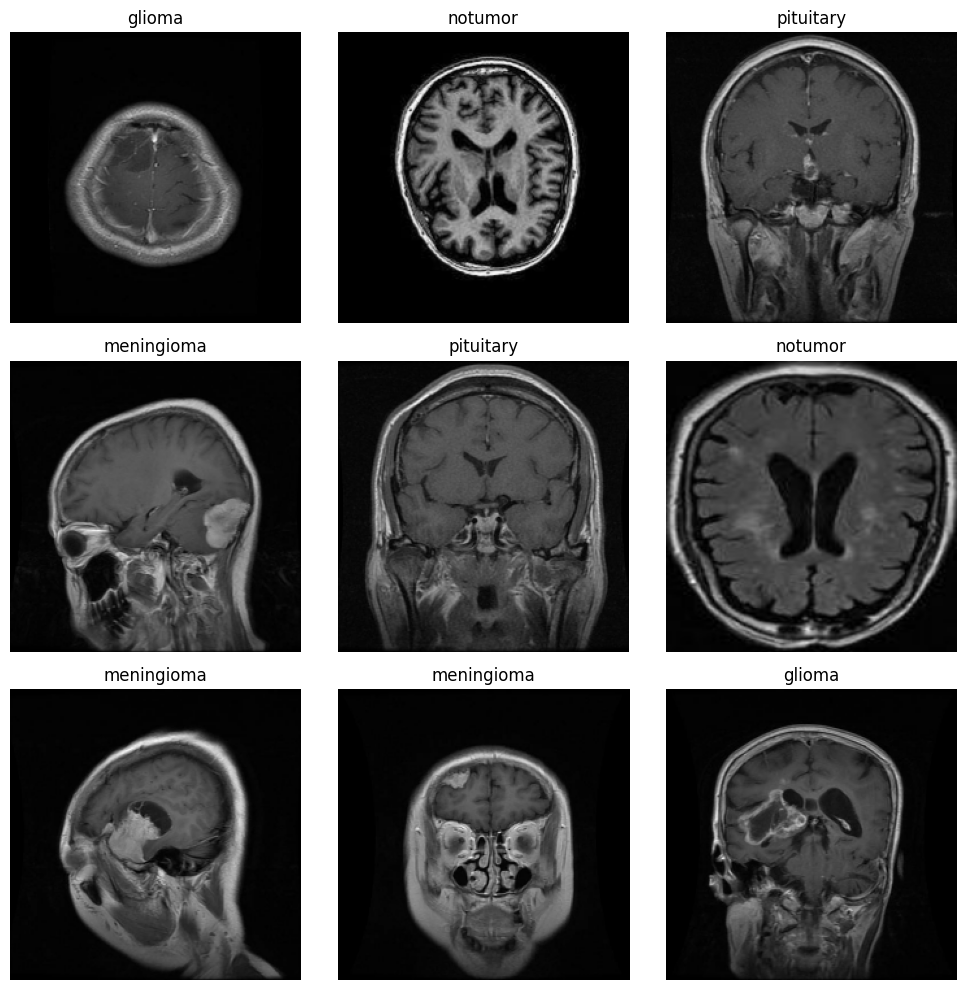

In [ ]:
# Display Sample Images
plt.figure(figsize=(10,10))

for images, labels in train_dataset.take(1):
    for i in range(9):
        plt.subplot(3,3,i+1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
#Check Pixel Values Before Normalization
for images, labels in train_dataset.take(1):
    print("Minimum Pixel:", images[0].numpy().min())
    print("Maximum Pixel:", images[0].numpy().max())

Minimum Pixel: 0.0
Maximum Pixel: 254.78773


In [ ]:
# Normalize Image
normalization_layer = tf.keras.layers.Rescaling(1./255)

In [ ]:
# Apply Normalization ( Run this Cell once)
train_dataset = train_dataset.map(
    lambda images, labels: (normalization_layer(images), labels)
)

validation_dataset = validation_dataset.map(
    lambda images, labels: (normalization_layer(images), labels)
)

In [ ]:
# Verify Normalization
for images, labels in train_dataset.take(1):
    print("Minimum Pixel:", images[0].numpy().min())
    print("Maximum Pixel:", images[0].numpy().max())

Minimum Pixel: 0.0
Maximum Pixel: 0.8927943


In [ ]:
#Optimize dataset Pipeline
AUTOTUNE = tf.data.AUTOTUNE

train_dataset = (
    train_dataset
    .cache()
    .shuffle(1000)
    .prefetch(AUTOTUNE)
)

validation_dataset = (
    validation_dataset
    .cache()
    .prefetch(AUTOTUNE)
)

In [ ]:
#Build CNN
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

model = Sequential([
    Conv2D(
        32,
        (3,3),
        activation="relu",
        input_shape=(224,224,3)
    ),

    MaxPooling2D((2,2)),

    Conv2D(
        64,
        (3,3),
        activation="relu"
    ),

    MaxPooling2D((2,2)),

    Flatten(),

    Dense(
        128,
        activation="relu"
    ),

    Dense(
        4,
        activation="softmax"
    )
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
#Compile The Model
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
# Model Summary
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 186624)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    23,888,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,907,908 (91.20 MB)

 Trainable params: 23,907,908 (91.20 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
#Train the Model
history = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=20
)

Epoch 1/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 938s 4s/step - accuracy: 0.7355 - loss: 0.7394 - val_accuracy: 0.8795 - val_loss: 0.3597
Epoch 2/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 468s 3s/step - accuracy: 0.9161 - loss: 0.2347 - val_accuracy: 0.8911 - val_loss: 0.3080
Epoch 3/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 501s 3s/step - accuracy: 0.9565 - loss: 0.1163 - val_accuracy: 0.9134 - val_loss: 0.2743
Epoch 4/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 469s 3s/step - accuracy: 0.9868 - loss: 0.0440 - val_accuracy: 0.9116 - val_loss: 0.3035
Epoch 5/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 467s 3s/step - accuracy: 0.9931 - loss: 0.0245 - val_accuracy: 0.9214 - val_loss: 0.2895
Epoch 6/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 463s 3s/step - accuracy: 0.9980 - loss: 0.0095 - val_accuracy: 0.9277 - val_loss: 0.3273
Epoch 7/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 503s 3s/step - accuracy: 0.9991 - loss: 0.0051 - val_accuracy: 0.9277 - val_loss: 0.2921
Epoch 8/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 461s 3s/step - accuracy: 0.9998 - loss: 9.7680e-04 - val_

In [ ]:
model.save("brain_tumor_cnn.keras")

In [ ]:
import pandas as pd

history_df = pd.DataFrame(history.history)
history_df.to_csv("training_history.csv", index=False)

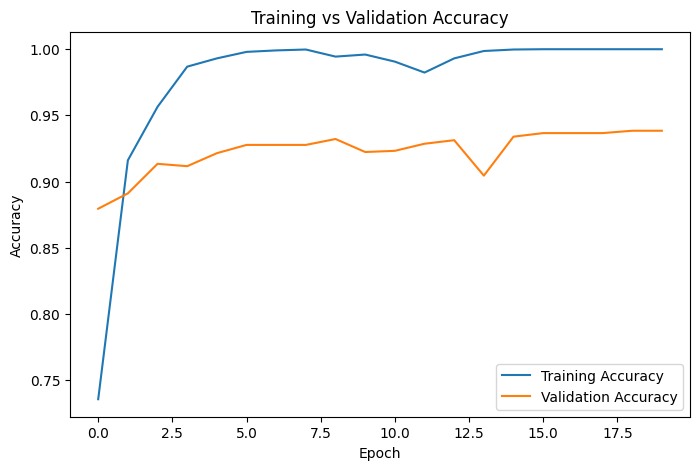

In [ ]:
#Plot Accuracy
plt.figure(figsize=(8,5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()

plt.show()

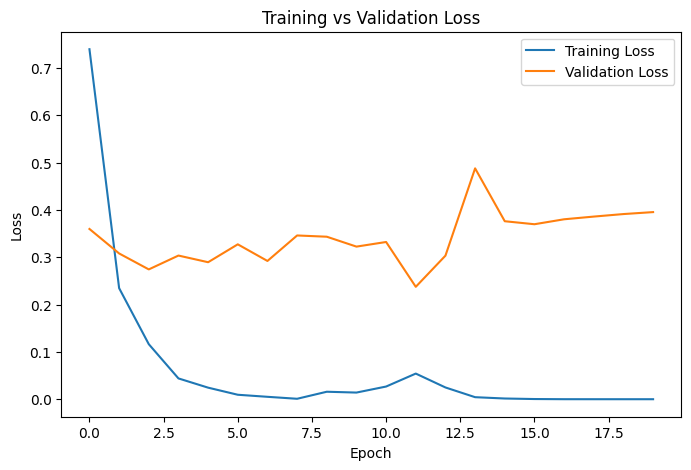

In [ ]:
#Plot Loss
plt.figure(figsize=(8,5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()

plt.show()

MOdel Evaluation

In [ ]:
test_path = "/content/drive/MyDrive/Deep Learning_Tumor detect/Testing"

In [ ]:
#Load Data Set
test_dataset = tf.keras.utils.image_dataset_from_directory(
    test_path,
    image_size=(224,224),
    batch_size=32,
    shuffle=False
)

Found 1600 files belonging to 4 classes.


In [ ]:
#Normalize the Data set
test_dataset = test_dataset.map(
    lambda images, labels: (normalization_layer(images), labels)
)

test_dataset = test_dataset.prefetch(tf.data.AUTOTUNE)

In [ ]:
#Evaluate the Model
test_loss, test_accuracy = model.evaluate(test_dataset)

50/50 ━━━━━━━━━━━━━━━━━━━━ 171s 3s/step - accuracy: 0.8712 - loss: 2.1771


In [ ]:
print("Test Loss :", test_loss)
print("Test Accuracy :", test_accuracy)

Test Loss : 2.1771109104156494
Test Accuracy : 0.8712499737739563


In [ ]:
#Confusion Matrix
from sklearn.metrics import confusion_matrix
import numpy as np

predictions = model.predict(test_dataset)
predicted_labels = np.argmax(predictions, axis=1)

true_labels = []

for images, labels in test_dataset:
    true_labels.extend(labels.numpy())

true_labels = np.array(true_labels)

cm = confusion_matrix(true_labels, predicted_labels)
print(cm)

50/50 ━━━━━━━━━━━━━━━━━━━━ 50s 994ms/step
[[289  52  49  10]
 [ 23 340  23  14]
 [  0   2 398   0]
 [  7  25   1 367]]


Predicted
              G   M   N   P
-Actual G    [289 52 49 10]
-Actual M    [23 340 23 14]
-Actual N    [0   2 398 0]
-Actual P    [7  25  1 367]

- Actual Glioma images = 400
Correct predictions: 289
Incorrect predictions:
Predicted as Meningioma = 52
Predicted as No Tumor = 49
Predicted as Pituitary = 10

- Meningioma 340 / 400
Most mistakes occur with:
Glioma
No Tumor

-No Tumor
This is excellent
Only 2 mistakes out of 400.

-Pituitary 367 / 400
Very strong performance

In [ ]:
#Classification Report
from sklearn.metrics import classification_report

print(
    classification_report(
        true_labels,
        predicted_labels,
        target_names=class_names
    )
)

              precision    recall  f1-score   support

      glioma       0.91      0.72      0.80       400
  meningioma       0.81      0.85      0.83       400
     notumor       0.85      0.99      0.91       400
   pituitary       0.94      0.92      0.93       400

    accuracy                           0.87      1600
   macro avg       0.88      0.87      0.87      1600
weighted avg       0.88      0.87      0.87      1600



- Glioma - When the model predicts Glioma, it is usually correct (91% precision).
However, it misses many actual Glioma cases (72% recall).
In medical applications, low recall for a disease is a concern because missed cases could delay diagnosis.
-Meningioma - Excellent recall.
The model almost never misses healthy patients.
- Pituitary -  Excellent.

-The Glioma class has the lowest recall (72%). This means the model misses a notable number of actual Glioma cases, often confusing them with Meningioma or No Tumor. Improving Glioma detection would be an important next step.

Predicted Tumor or Not Using Images from internet

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
class_names = [
    "glioma",
    "meningioma",
    "notumor",
    "pituitary"
]

In [ ]:
image_path = "/content/Brain_sample.png"

In [ ]:
#Load the MRI Image
image = tf.keras.preprocessing.image.load_img(
    image_path,
    target_size=(224,224)
)

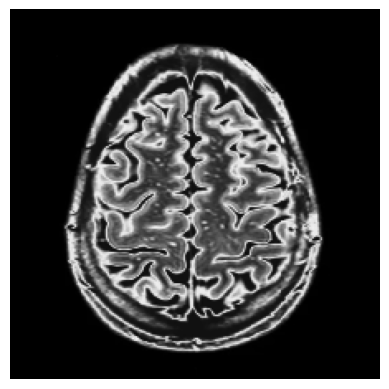

In [ ]:
#Display the Image
plt.imshow(image)
plt.axis("off")
plt.show()

In [ ]:
#Convert Image to NumPy Array
image_array = tf.keras.preprocessing.image.img_to_array(image)

In [ ]:
#Normalize the Image
image_array = image_array / 255.0

In [ ]:
#Add Batch Dimension
image_array = np.expand_dims(image_array, axis=0)

In [ ]:
#Make Prediction
prediction = model.predict(image_array)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 186ms/step


In [ ]:
print(prediction)

[[8.255652e-28 8.133526e-12 1.000000e+00 1.841102e-20]]


In [ ]:
predicted_index = np.argmax(prediction)

predicted_class = class_names[predicted_index]

print("Predicted Class :", predicted_class)

Predicted Class : notumor


In [ ]:
#Prediciton Confidence
confidence = prediction[0][predicted_index] * 100

print(f"Confidence : {confidence:.2f}%")

Confidence : 100.00%
